In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import numpy as np

In [ ]:
train = pd.read_csv("../data/raw/train.csv")

In [ ]:
train.shape

(1460, 81)

In [ ]:
train.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [ ]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

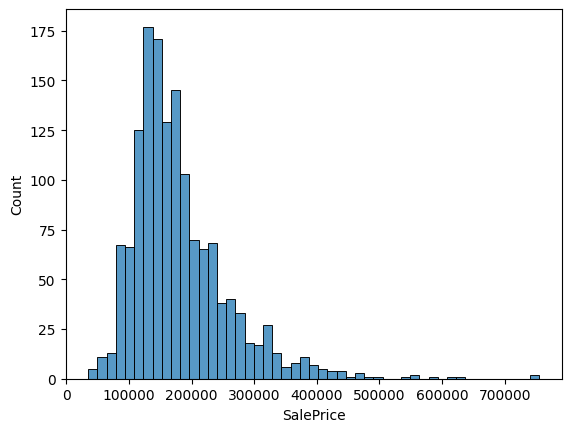

In [ ]:
sns.histplot(train, x="SalePrice")
plt.show()

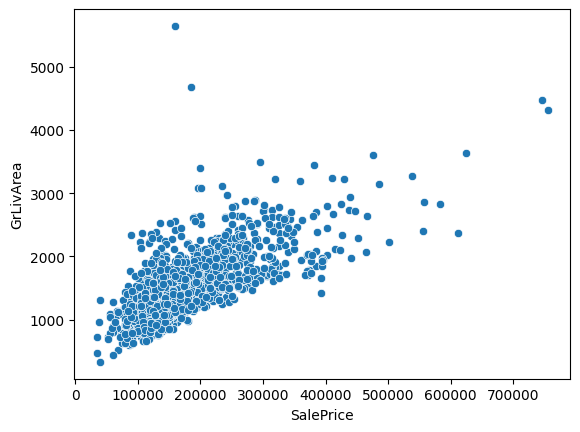

In [ ]:
sns.scatterplot(data=train, x="SalePrice", y="GrLivArea")
plt.show()

In [ ]:
mean_prices_byquality = train.groupby("OverallQual")["SalePrice"].mean().sort_values()
type(mean_prices_byquality)
mean_prices_byquality

OverallQual
1      50150.000000
2      51770.333333
3      87473.750000
4     108420.655172
5     133523.347607
6     161603.034759
7     207716.423197
8     274735.535714
9     367513.023256
10    438588.388889
Name: SalePrice, dtype: float64

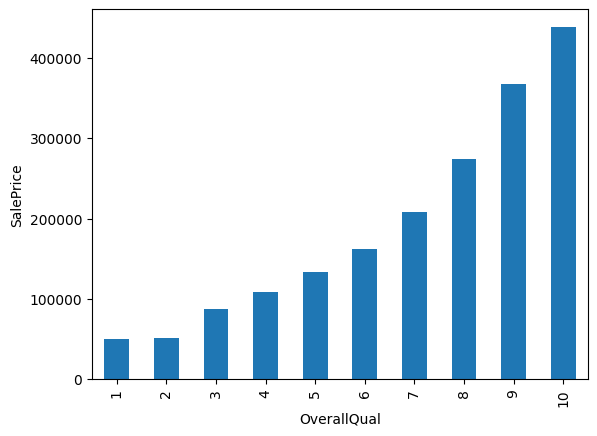

In [ ]:
mean_prices_byquality.plot(kind="bar")
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.show()

In [ ]:
columns = train.columns
type(columns)

pandas.Index

In [ ]:
null_columns = train.isnull().sum()[train.isnull().sum()>0].sort_values(ascending=False)
null_columns

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

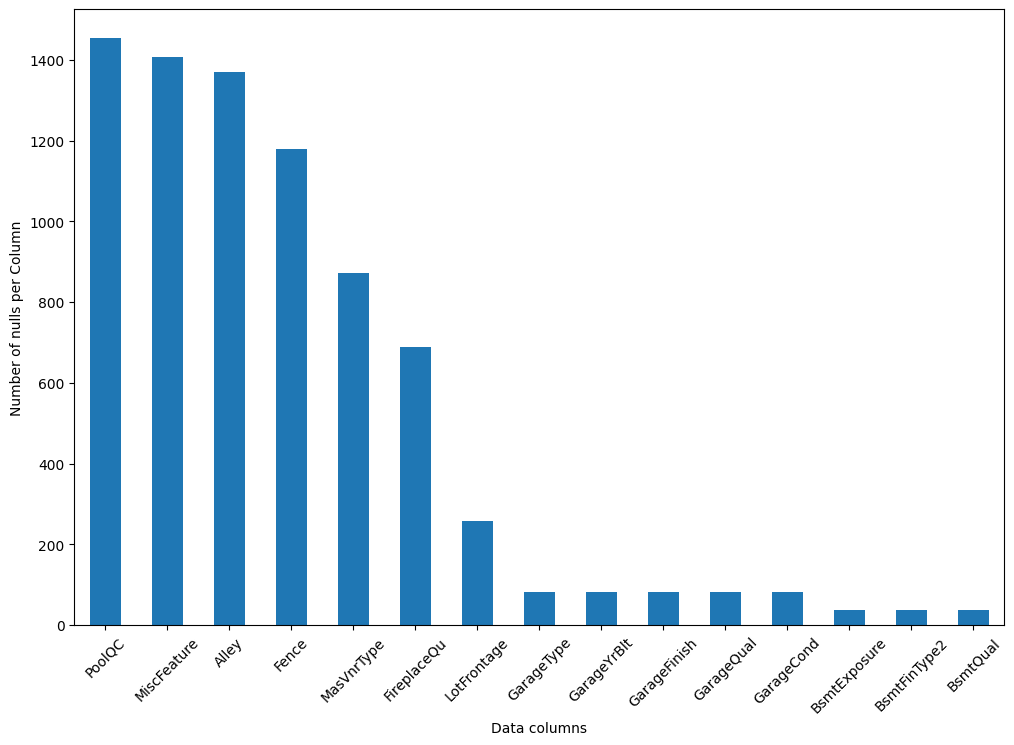

In [ ]:
top_nulls = null_columns.head(15)
top_nulls.plot(kind="bar", figsize=(12,8))
plt.xticks(rotation=45)
plt.xlabel("Data columns")
plt.ylabel("Number of nulls per Column")
plt.show()

In [ ]:
clean_train = train.drop("Id", axis=1)

In [ ]:
categorical_with_nulls = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "MasVnrType",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtExposure",
    "BsmtFinType2",
    "BsmtQual",
    "BsmtCond",
    "BsmtFinType1",
]
for column in categorical_with_nulls:
    clean_train[column] = clean_train[column].fillna("None")

In [ ]:
numerical_with_nulls = ["LotFrontage", "GarageYrBlt","MasVnrArea"]
for column in numerical_with_nulls:
    median = clean_train[column].median()
    clean_train[column] = clean_train[column].fillna(median)


In [ ]:
idx_max = clean_train["Electrical"].value_counts().idxmax()
clean_train["Electrical"] = clean_train["Electrical"].fillna(idx_max)

In [ ]:
clean_train.isnull().sum()[clean_train.isnull().sum() > 0].sort_values()

Series([], dtype: int64)

In [ ]:
x = clean_train.drop("SalePrice", axis=1)
print("x shape:", x.shape)
y = clean_train["SalePrice"]
print("y shape:",y.shape)

x shape: (1460, 79)
y shape: (1460,)


In [ ]:
num_features_names = [
    "LotFrontage",
    "LotArea",
    "OverallQual",
    "OverallCond",
    "YearBuilt",
    "YearRemodAdd",
    "MasVnrArea",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "1stFlrSF",
    "2ndFlrSF",
    "LowQualFinSF",
    "GrLivArea",
    "BsmtFullBath",
    "BsmtHalfBath",
    "FullBath",
    "HalfBath",
    "BedroomAbvGr",
    "KitchenAbvGr",
    "TotRmsAbvGrd",
    "Fireplaces",
    "GarageYrBlt",
    "GarageCars",
    "GarageArea",
    "WoodDeckSF",
    "OpenPorchSF",
    "EnclosedPorch",
    "3SsnPorch",
    "ScreenPorch",
    "PoolArea",
    "MiscVal",
]
num_features = x[num_features_names]
print("shape numerical features: ", num_features.shape)
cat_features_names = [
    "MSZoning",
    "Street",
    "Alley",
    "LotShape",
    "LandContour",
    "Utilities",
    "LotConfig",
    "LandSlope",
    "Neighborhood",
    "Condition1",
    "Condition2",
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "RoofMatl",
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "ExterQual",
    "ExterCond",
    "Foundation",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "Heating",
    "HeatingQC",
    "CentralAir",
    "Electrical",
    "KitchenQual",
    "Functional",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PavedDrive",
    "PoolQC",
    "Fence",
    "MiscFeature",
    "SaleType",
    "SaleCondition",
    "MSSubClass",
    "MoSold",
    "YrSold",
]
cat_features = x[cat_features_names]
print("shape categorical features: ",cat_features.shape)

shape numerical features:  (1460, 33)
shape categorical features:  (1460, 46)


In [ ]:
x_encoded = pd.get_dummies(x, columns=cat_features_names, drop_first=True)

In [ ]:
x_encoded.shape

(1460, 285)

In [ ]:
x_encoded.head()
#"MSSubClass", "MoSold", "YrSold"

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,MoSold_7,MoSold_8,MoSold_9,MoSold_10,MoSold_11,MoSold_12,YrSold_2007,YrSold_2008,YrSold_2009,YrSold_2010
0,65.0,8450,7,5,2003,2003,196.0,706,0,150,...,False,False,False,False,False,False,False,True,False,False
1,80.0,9600,6,8,1976,1976,0.0,978,0,284,...,False,False,False,False,False,False,True,False,False,False
2,68.0,11250,7,5,2001,2002,162.0,486,0,434,...,False,False,True,False,False,False,False,True,False,False
3,60.0,9550,7,5,1915,1970,0.0,216,0,540,...,False,False,False,False,False,False,False,False,False,False
4,84.0,14260,8,5,2000,2000,350.0,655,0,490,...,False,False,False,False,False,True,False,True,False,False


In [ ]:
X_train ,X_valid ,y_train ,y_valid = train_test_split(x_encoded, y, test_size=0.2, random_state=42)

In [ ]:
print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (1168, 285)
X_valid shape: (292, 285)
y_train shape: (1168,)
y_valid shape: (292,)


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred = model.predict(X_valid)

In [ ]:
rmse = root_mean_squared_error(y_valid, y_pred)
print(f"rmse = {rmse}")

rmse = 89670.7576055459


# Fix the Target

In [ ]:
y_train_log = np.log(y_train)

In [ ]:
model.fit(X_train, y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
y_pred_log = model.predict(X_valid)

In [ ]:
y_pred = np.exp(y_pred_log)

In [ ]:
rmse = root_mean_squared_error(y_valid, y_pred)
print(f"rmse = {rmse}")

rmse = 25673.581993054733
